# Ripeness Prediction — Model Training

Trains three CNN architectures (MobileNetV2, EfficientNetB0, ResNet50) using two-phase transfer learning. Each model uses its own correct `preprocess_input` function — the single most important fix vs the original.

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import mobilenet_v2, efficientnet, resnet50
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow Version:", tf.__version__)


2026-05-29 15:29:19.205918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780068559.594358      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780068559.709034      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780068560.670994      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780068560.671031      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780068560.671034      58 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


# Paths and Parameters

In [3]:
DATASET_PATH = "/kaggle/input/datasets/ritika156/dataset2/kaggle/working/clean_dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

IMG_SIZE   = 224
BATCH_SIZE = 32


# Data Generators — One Per Model

**Why separate generators?** Each architecture was pretrained with a different normalization scheme:
- `MobileNetV2` — expects inputs scaled to `[-1, 1]` via its own `preprocess_input`
- `EfficientNetB0` — expects raw pixel values `[0, 255]`; it handles normalization internally. Using `rescale=1./255` here is what caused ~17% accuracy in the original.
- `ResNet50` — expects channel-mean subtraction (ImageNet means per channel)

Using `rescale=1./255` for all three (as in the original code) silently breaks EfficientNet and ResNet.

In [4]:
# Augmentation settings shared across all three (applied before preprocess_input)
AUG_PARAMS = dict(
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# --- MobileNetV2 ---
mobilenet_train_datagen = ImageDataGenerator(preprocessing_function=mobilenet_v2.preprocess_input, **AUG_PARAMS)
mobilenet_test_datagen  = ImageDataGenerator(preprocessing_function=mobilenet_v2.preprocess_input)

# --- EfficientNetB0 ---
# DO NOT add rescale=1./255 here — EfficientNet does its own normalization internally
efficientnet_train_datagen = ImageDataGenerator(preprocessing_function=efficientnet.preprocess_input, **AUG_PARAMS)
efficientnet_test_datagen  = ImageDataGenerator(preprocessing_function=efficientnet.preprocess_input)

# --- ResNet50 ---
resnet_train_datagen = ImageDataGenerator(preprocessing_function=resnet50.preprocess_input, **AUG_PARAMS)
resnet_test_datagen  = ImageDataGenerator(preprocessing_function=resnet50.preprocess_input)


In [5]:
def make_generators(train_dg, test_dg):
    train = train_dg.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', subset='training'
    )
    val = train_dg.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', subset='validation'
    )
    test = test_dg.flow_from_directory(
        TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
    return train, val, test

mobilenet_train,    mobilenet_val,    mobilenet_test    = make_generators(mobilenet_train_datagen,    mobilenet_test_datagen)
efficientnet_train, efficientnet_val, efficientnet_test = make_generators(efficientnet_train_datagen, efficientnet_test_datagen)
resnet_train,       resnet_val,       resnet_test       = make_generators(resnet_train_datagen,       resnet_test_datagen)

# Class info (same across all generators — same underlying folder)
class_names = list(mobilenet_train.class_indices.keys())
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Num classes:", NUM_CLASSES)


Found 12974 images belonging to 3 classes.
Found 3243 images belonging to 3 classes.
Found 180 images belonging to 3 classes.
Found 12974 images belonging to 3 classes.
Found 3243 images belonging to 3 classes.
Found 180 images belonging to 3 classes.
Found 12974 images belonging to 3 classes.
Found 3243 images belonging to 3 classes.
Found 180 images belonging to 3 classes.
Classes: ['overripe', 'ripe', 'unripe']
Num classes: 3


# Class Weights — Handle Dataset Imbalance

If one ripeness class has significantly more images, the model will learn to predict it more often and report inflated accuracy. `class_weight` penalises wrong predictions on underrepresented classes more heavily.

In [6]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(mobilenet_train.classes),
    y=mobilenet_train.classes
)
class_weight_dict = dict(enumerate(class_weights_array))

print("Class weights:")
for idx, cname in enumerate(class_names):
    print(f"  {cname}: {class_weight_dict[idx]:.3f}")


Class weights:
  overripe: 0.877
  ripe: 1.140
  unripe: 1.017


# Model Architecture — Classification Head

All three models share the same head structure on top of their respective pretrained base. The base is frozen in Phase 1, then partially unfrozen in Phase 2.

In [7]:
def build_model(base_model, model_name):
    print(f"\nBuilding {model_name}...")

    base_model.trainable = False  # Frozen for Phase 1

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Build All Three Models

In [8]:
mobilenet_base = tf.keras.applications.MobileNetV2(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
mobilenet_model = build_model(mobilenet_base, "MobileNetV2")


I0000 00:00:1780068596.768764      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780068596.774710      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Building MobileNetV2...


In [9]:
efficientnet_base = tf.keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
efficientnet_model = build_model(efficientnet_base, "EfficientNetB0")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Building EfficientNetB0...


In [10]:
resnet_base = tf.keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
resnet_model = build_model(resnet_base, "ResNet50")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Building ResNet50...


# Two-Phase Training Function

**Phase 1** — Base is fully frozen. Only the classification head trains. High learning rate `1e-3`. This converges quickly.

**Phase 2** — Top layers of the base are unfrozen. The whole model is retrained at a very low learning rate `1e-5`. This is where the model adapts its deep features to your fruit data and is where most accuracy gains come from.

The number of layers to unfreeze differs per architecture:
- `MobileNetV2` → last 30 layers (last few inverted residual blocks)
- `EfficientNetB0` → last 20 layers (top MBConv blocks)
- `ResNet50` → last 15 layers (the `conv5` residual block)

In [11]:
def train_model(model, model_name, train_data, valid_data, unfreeze_from_layer):

    callbacks_phase1 = [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]

    # ── PHASE 1: Train head only ───────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"[{model_name}] Phase 1: Training classification head (base frozen)")
    print(f"{'='*60}")

    history1 = model.fit(
        train_data,
        validation_data=valid_data,
        epochs=15,
        class_weight=class_weight_dict,
        callbacks=callbacks_phase1,
        verbose=1
    )

    # ── PHASE 2: Fine-tune top layers of base ─────────────────────────────
    print(f"\n{'='*60}")
    print(f"[{model_name}] Phase 2: Fine-tuning top {unfreeze_from_layer} layers")
    print(f"{'='*60}")

    # Unfreeze the base model
    model.layers[0].trainable = True

    # Re-freeze all except the last `unfreeze_from_layer` layers
    for layer in model.layers[0].layers[:-unfreeze_from_layer]:
        layer.trainable = False

    trainable_count = sum(1 for l in model.layers[0].layers if l.trainable)
    print(f"  Trainable layers in base: {trainable_count}")

    # Recompile at low LR — crucial, otherwise fine-tuning destroys pretrained weights
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_phase2 = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)
    ]

    history2 = model.fit(
        train_data,
        validation_data=valid_data,
        epochs=20,
        class_weight=class_weight_dict,
        callbacks=callbacks_phase2,
        verbose=1
    )

    return history1, history2


# Train All Three Models

In [12]:
mobilenet_h1, mobilenet_h2 = train_model(
    mobilenet_model, "MobileNetV2",
    mobilenet_train, mobilenet_val,
    unfreeze_from_layer=30
)



[MobileNetV2] Phase 1: Training classification head (base frozen)
Epoch 1/15


I0000 00:00:1780068661.776694     193 service.cc:152] XLA service 0x7fb468010800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780068661.776757     193 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780068661.776763     193 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780068663.085470     193 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-29 15:31:13.373036: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 15:31:13.509611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1780068676.387373     193 device_co

343/406 ━━━━━━━━━━━━━━━━━━━━ 36s 576ms/step - accuracy: 0.8837 - loss: 0.3064

2026-05-29 15:34:42.451544: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 15:34:42.587685: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8915 - loss: 0.2875

2026-05-29 15:36:34.704586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 15:36:34.840522: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


406/406 ━━━━━━━━━━━━━━━━━━━━ 341s 790ms/step - accuracy: 0.9363 - loss: 0.1779 - val_accuracy: 0.9880 - val_loss: 0.0300 - learning_rate: 0.0010
Epoch 2/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 202s 497ms/step - accuracy: 0.9709 - loss: 0.0890 - val_accuracy: 0.9914 - val_loss: 0.0329 - learning_rate: 0.0010
Epoch 3/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9766 - loss: 0.0741
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
406/406 ━━━━━━━━━━━━━━━━━━━━ 195s 481ms/step - accuracy: 0.9773 - loss: 0.0685 - val_accuracy: 0.9877 - val_loss: 0.0353 - learning_rate: 0.0010
Epoch 4/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 202s 497ms/step - accuracy: 0.9858 - loss: 0.0408 - val_accuracy: 0.9963 - val_loss: 0.0109 - learning_rate: 5.0000e-04
Epoch 5/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 200s 492ms/step - accuracy: 0.9896 - loss: 0.0307 - val_accuracy: 0.9963 - val_loss: 0.0097 - learning_rate: 5.0000e-04
Epoch 6/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 200s 493ms/step - accuracy: 0.

In [13]:
efficientnet_h1, efficientnet_h2 = train_model(
    efficientnet_model, "EfficientNetB0",
    efficientnet_train, efficientnet_val,
    unfreeze_from_layer=20
)



[EfficientNetB0] Phase 1: Training classification head (base frozen)
Epoch 1/15


2026-05-29 17:28:01.348906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:28:01.492707: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:28:01.845804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:28:01.987059: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:28:02.128124: E external/local_xla/xla/stream_

 35/406 ━━━━━━━━━━━━━━━━━━━━ 2:35 420ms/step - accuracy: 0.7199 - loss: 0.7732

2026-05-29 17:28:29.936097: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:28:30.075402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:28:30.392398: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:28:30.533641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:28:31.330696: E external/local_xla/xla/stream_

406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9003 - loss: 0.2818

2026-05-29 17:32:15.347742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:32:15.486173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:32:15.800316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:32:15.941520: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 17:32:16.741622: E external/local_xla/xla/stream_

406/406 ━━━━━━━━━━━━━━━━━━━━ 275s 618ms/step - accuracy: 0.9432 - loss: 0.1669 - val_accuracy: 0.9966 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 2/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 216s 532ms/step - accuracy: 0.9749 - loss: 0.0768 - val_accuracy: 0.9923 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 3/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 215s 529ms/step - accuracy: 0.9813 - loss: 0.0570 - val_accuracy: 0.9975 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 4/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 217s 534ms/step - accuracy: 0.9857 - loss: 0.0422 - val_accuracy: 0.9985 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 5/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9862 - loss: 0.0377
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
406/406 ━━━━━━━━━━━━━━━━━━━━ 214s 528ms/step - accuracy: 0.9871 - loss: 0.0393 - val_accuracy: 0.9963 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 6/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 215s 529ms/step - accuracy: 0.9897 - l

In [14]:
resnet_h1, resnet_h2 = train_model(
    resnet_model, "ResNet50",
    resnet_train, resnet_val,
    unfreeze_from_layer=15
)



[ResNet50] Phase 1: Training classification head (base frozen)
Epoch 1/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 245s 569ms/step - accuracy: 0.9427 - loss: 0.1751 - val_accuracy: 0.9883 - val_loss: 0.0333 - learning_rate: 0.0010
Epoch 2/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 212s 523ms/step - accuracy: 0.9751 - loss: 0.0718 - val_accuracy: 0.9917 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 3/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 208s 513ms/step - accuracy: 0.9810 - loss: 0.0575 - val_accuracy: 0.9978 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 4/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 209s 515ms/step - accuracy: 0.9849 - loss: 0.0472 - val_accuracy: 0.9969 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 5/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 210s 517ms/step - accuracy: 0.9892 - loss: 0.0328 - val_accuracy: 0.9938 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 6/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 212s 522ms/step - accuracy: 0.9897 - loss: 0.0336 - val_accuracy: 0.9972 - val_loss: 0.0068 - learning_rate: 0.0010


# Training History Plots

Plotting Phase 1 and Phase 2 together gives you a clear picture of how much fine-tuning helped.

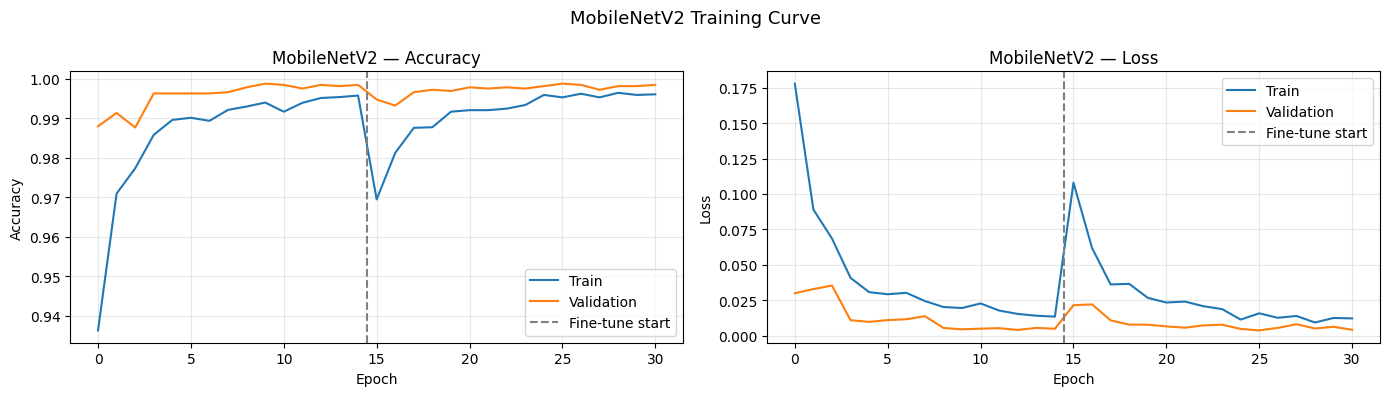

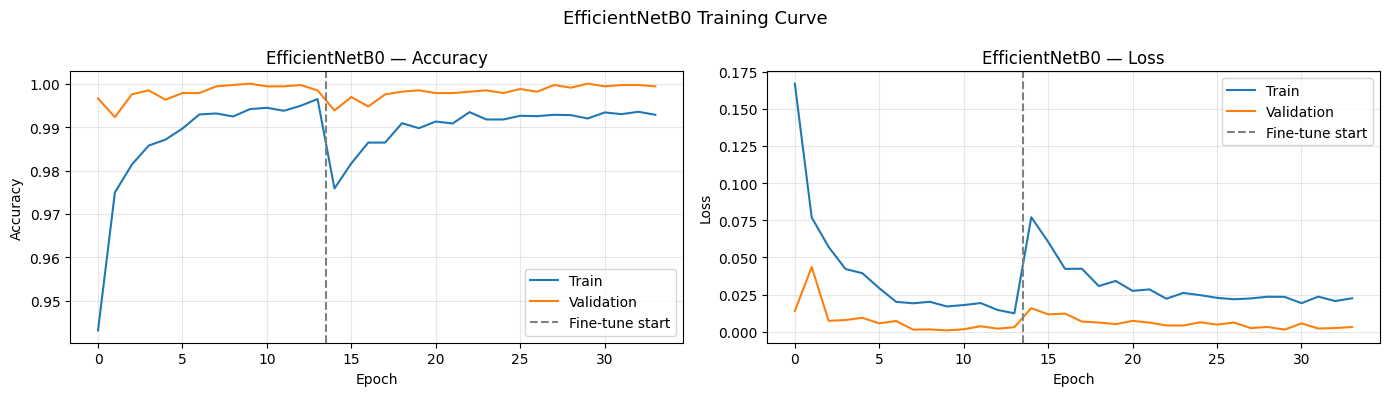

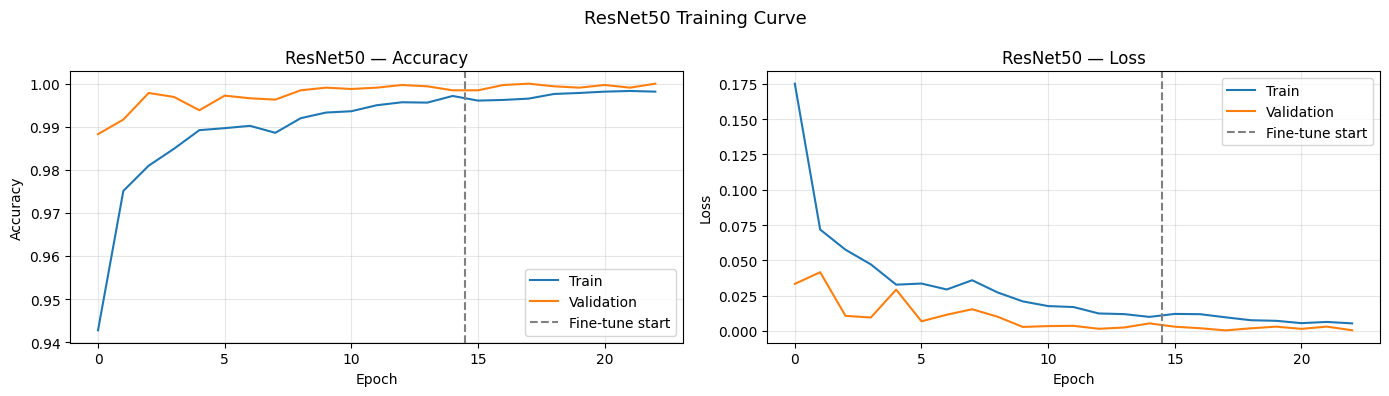

In [15]:
def plot_history(h1, h2, model_name):
    # Stitch the two phase histories together
    acc  = h1.history['accuracy']      + h2.history['accuracy']
    val  = h1.history['val_accuracy']  + h2.history['val_accuracy']
    loss = h1.history['loss']          + h2.history['loss']
    vloss= h1.history['val_loss']      + h2.history['val_loss']

    phase_boundary = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, train_vals, val_vals, ylabel in [
        (axes[0], acc,  val,  "Accuracy"),
        (axes[1], loss, vloss, "Loss")
    ]:
        ax.plot(train_vals, label="Train")
        ax.plot(val_vals,   label="Validation")
        ax.axvline(x=phase_boundary - 0.5, color='gray', linestyle='--', label='Fine-tune start')
        ax.set_title(f"{model_name} — {ylabel}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(f"{model_name} Training Curve", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{model_name}_training_curve.png", dpi=150)
    plt.show()

plot_history(mobilenet_h1,    mobilenet_h2,    "MobileNetV2")
plot_history(efficientnet_h1, efficientnet_h2, "EfficientNetB0")
plot_history(resnet_h1,       resnet_h2,       "ResNet50")


# Evaluation with Confusion Matrix


Evaluating MobileNetV2
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7714 - loss: 1.2050

2026-05-29 20:58:08.723377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 20:58:08.860559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7222 - loss: 1.5399 
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 874ms/step

MobileNetV2 — Accuracy: 0.7222 | Loss: 1.5399

Classification Report:
              precision    recall  f1-score   support

    overripe       0.79      0.87      0.83        60
        ripe       0.67      0.53      0.59        60
      unripe       0.70      0.77      0.73        60

    accuracy                           0.72       180
   macro avg       0.72      0.72      0.72       180
weighted avg       0.72      0.72      0.72       180



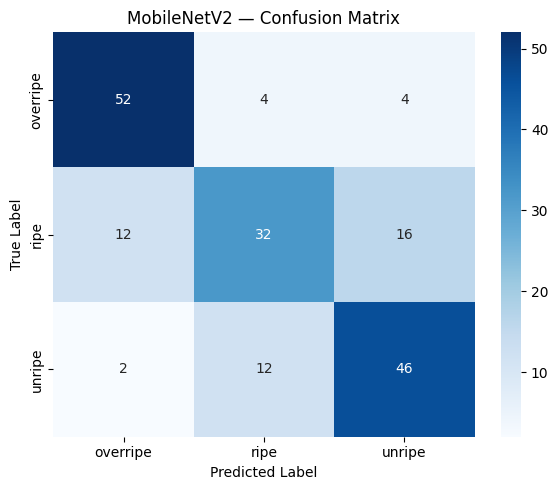


Evaluating EfficientNetB0
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7382 - loss: 1.8909

2026-05-29 20:58:23.957980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 20:58:24.099206: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 20:58:24.422103: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 20:58:24.562683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 20:58:25.314402: E external/local_xla/xla/stream_

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7167 - loss: 1.9374 
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step

EfficientNetB0 — Accuracy: 0.7167 | Loss: 1.9374

Classification Report:
              precision    recall  f1-score   support

    overripe       0.80      0.78      0.79        60
        ripe       0.77      0.60      0.67        60
      unripe       0.62      0.77      0.69        60

    accuracy                           0.72       180
   macro avg       0.73      0.72      0.72       180
weighted avg       0.73      0.72      0.72       180



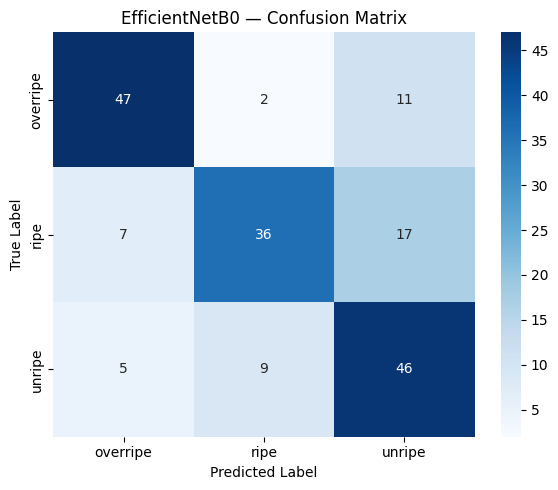


Evaluating ResNet50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 764ms/step - accuracy: 0.7389 - loss: 1.2242
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 799ms/step

ResNet50 — Accuracy: 0.7389 | Loss: 1.2242

Classification Report:
              precision    recall  f1-score   support

    overripe       0.86      0.82      0.84        60
        ripe       0.75      0.63      0.68        60
      unripe       0.64      0.77      0.70        60

    accuracy                           0.74       180
   macro avg       0.75      0.74      0.74       180
weighted avg       0.75      0.74      0.74       180



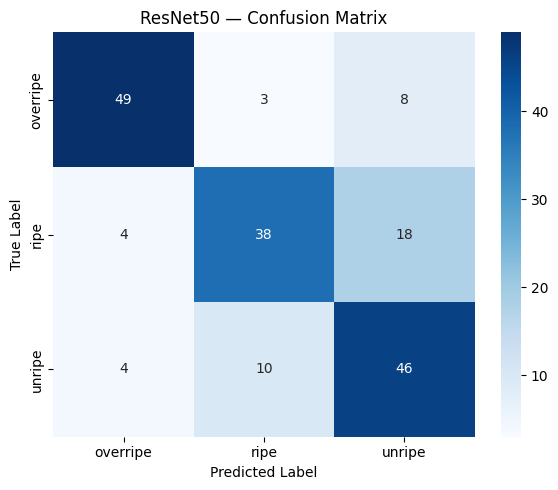

In [16]:
def evaluate_model(model, model_name, test_data):

    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print(f"{'='*60}")

    loss, accuracy = model.evaluate(test_data, verbose=1)

    predictions       = model.predict(test_data)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes      = test_data.classes

    print(f"\n{model_name} — Accuracy: {accuracy:.4f} | Loss: {loss:.4f}")

    print("\nClassification Report:")
    print(classification_report(true_classes, predicted_classes, target_names=class_names))

    # Confusion matrix — save as PNG for README
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png", dpi=150)
    plt.show()

    return accuracy

mobilenet_acc    = evaluate_model(mobilenet_model,    "MobileNetV2",    mobilenet_test)
efficientnet_acc = evaluate_model(efficientnet_model, "EfficientNetB0", efficientnet_test)
resnet_acc       = evaluate_model(resnet_model,       "ResNet50",       resnet_test)


# Ensemble — Weighted Average of All Three Models

Combine all three models by weighting each model's predictions by its individual accuracy. A stronger model contributes more to the final decision. This typically adds 2–5% over the best individual model.


Evaluating Weighted Ensemble...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
Ensemble weights — MobileNet: 0.332 | EfficientNet: 0.329 | ResNet: 0.339

Ensemble Accuracy: 0.7389

Classification Report:
              precision    recall  f1-score   support

    overripe       0.81      0.78      0.80        60
        ripe       0.79      0.63      0.70        60
      unripe       0.65      0.80      0.72        60

    accuracy                           0.74       180
   macro avg       0.75      0.74      0.74       180
weighted avg       0.75      0.74      0.74       180



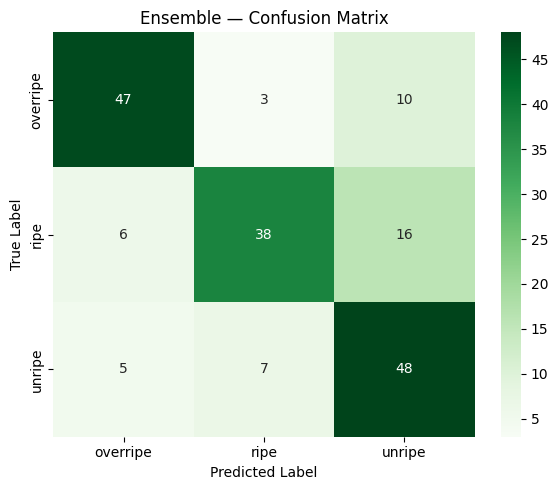

In [17]:
print("\nEvaluating Weighted Ensemble...")

# Get raw softmax predictions from each model on their respective test sets
# (same underlying images, different preprocessing — predictions are on the same test folder)
pred1 = mobilenet_model.predict(mobilenet_test)
pred2 = efficientnet_model.predict(efficientnet_test)
pred3 = resnet_model.predict(resnet_test)

# Weight each model proportionally by its accuracy
total = mobilenet_acc + efficientnet_acc + resnet_acc
w1, w2, w3 = mobilenet_acc / total, efficientnet_acc / total, resnet_acc / total

print(f"Ensemble weights — MobileNet: {w1:.3f} | EfficientNet: {w2:.3f} | ResNet: {w3:.3f}")

ensemble_preds   = (w1 * pred1) + (w2 * pred2) + (w3 * pred3)
ensemble_classes = np.argmax(ensemble_preds, axis=1)
true_classes     = mobilenet_test.classes   # same true labels across all test generators

ensemble_acc = np.mean(ensemble_classes == true_classes)

print(f"\nEnsemble Accuracy: {ensemble_acc:.4f}")
print("\nClassification Report:")
print(classification_report(true_classes, ensemble_classes, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(true_classes, ensemble_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Ensemble — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("ensemble_confusion_matrix.png", dpi=150)
plt.show()


# Final Model Comparison


MODEL COMPARISON
              Model  Accuracy
        MobileNetV2  0.722222
     EfficientNetB0  0.716667
           ResNet50  0.738889
Ensemble (Weighted)  0.738889


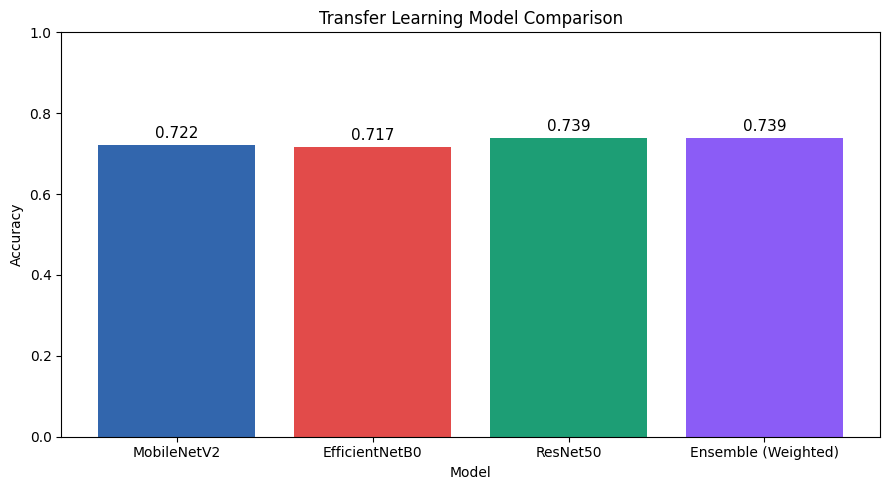

In [18]:
results = pd.DataFrame({
    "Model":    ["MobileNetV2", "EfficientNetB0", "ResNet50", "Ensemble (Weighted)"],
    "Accuracy": [mobilenet_acc, efficientnet_acc, resnet_acc, ensemble_acc]
})

print("\nMODEL COMPARISON")
print(results.to_string(index=False))

plt.figure(figsize=(9, 5))
colors = ["#3266ad", "#E24B4A", "#1D9E75", "#8B5CF6"]
bars = plt.bar(results["Model"], results["Accuracy"], color=colors)
plt.title("Transfer Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for bar, acc in zip(bars, results["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.3f}", ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()


# Save Models

In [19]:
mobilenet_model.save("mobilenet_model.h5")
efficientnet_model.save("efficientnet_model.h5")
resnet_model.save("resnet_model.h5")

print("All models saved.")
print("Also saving ensemble weights for deployment:")

ensemble_weights = {"w1": float(w1), "w2": float(w2), "w3": float(w3)}
import json
with open("ensemble_weights.json", "w") as f:
    json.dump(ensemble_weights, f)
print("Ensemble weights saved to ensemble_weights.json")


All models saved.
Also saving ensemble weights for deployment:
Ensemble weights saved to ensemble_weights.json
